# Notebook 03 — Evaluate & compare

**Input:** PhoBERT artifacts + `baseline.pkl` + val split  
**Output:** `model/report.md`

Side-by-side metrics, confusion matrices, and error analysis.

In [1]:
import json
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from pyvi.ViTokenizer import tokenize
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from transformers import AutoModelForSequenceClassification, AutoTokenizer

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent.parent
elif not (PROJECT_ROOT / "model" / "config.py").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from model.config import (
    BASELINE_PKL_PATH,
    LABELED_CSV_PATH,
    PHOBERT_ARTIFACTS_DIR,
    REPORT_PATH,
    SPLIT_INDICES_PATH,
)

LABELS = ["negative", "neutral", "positive"]
MAX_LENGTH = 128
sns.set_theme(style="whitegrid")

## 1. Load validation set + both models

In [2]:
with SPLIT_INDICES_PATH.open(encoding="utf-8") as f:
    split = json.load(f)

df = pd.read_csv(LABELED_CSV_PATH)
val_df = df.loc[split["val_indices"]].reset_index(drop=True)
y_true = val_df["sentiment"]

# Baseline
if not BASELINE_PKL_PATH.exists():
    raise FileNotFoundError(f"Run notebook 02 first — missing {BASELINE_PKL_PATH}")
baseline = joblib.load(BASELINE_PKL_PATH)

def baseline_preprocess(text: str) -> str:
    return tokenize(" ".join(str(text).split())).lower()

y_pred_baseline = baseline.predict(val_df["comment"].map(baseline_preprocess))

# PhoBERT
weights = PHOBERT_ARTIFACTS_DIR / "model.safetensors"
if not weights.exists():
    raise FileNotFoundError(
        f"Run notebook 01 export first — missing weights in {PHOBERT_ARTIFACTS_DIR}"
    )

with (PHOBERT_ARTIFACTS_DIR / "label_map.json").open(encoding="utf-8") as f:
    id2label = {int(k): v for k, v in json.load(f).items()}

device = "mps" if torch.backends.mps.is_available() else "cpu"
tokenizer = AutoTokenizer.from_pretrained(PHOBERT_ARTIFACTS_DIR)
phobert = AutoModelForSequenceClassification.from_pretrained(PHOBERT_ARTIFACTS_DIR)
phobert.to(device)
phobert.eval()

def phobert_preprocess(text: str) -> str:
    return tokenize(" ".join(str(text).split()))

def predict_phobert(texts):
    preds = []
    for text in texts:
        inputs = tokenizer(
            phobert_preprocess(text),
            return_tensors="pt",
            truncation=True,
            max_length=MAX_LENGTH,
        )
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            pred_id = int(phobert(**inputs).logits.argmax(dim=-1).item())
        preds.append(id2label[pred_id])
    return preds

y_pred_phobert = predict_phobert(val_df["comment"].tolist())
print(f"Val rows: {len(val_df)}")
print("Models loaded.")

Val rows: 200
Models loaded.


## 2. Comparison table

**Macro-F1** is primary (balanced across 3 classes). Accuracy shown but not trusted alone on imbalanced data.

In [3]:
def metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
    }

rows = [
    {"model": "PhoBERT", **metrics(y_true, y_pred_phobert)},
    {"model": "TF-IDF + LR", **metrics(y_true, y_pred_baseline)},
]
compare_df = pd.DataFrame(rows).set_index("model")
compare_df = compare_df.round(3)
display(compare_df)

print("\nPhoBERT per-class:")
print(classification_report(y_true, y_pred_phobert, target_names=LABELS))
print("Baseline per-class:")
print(classification_report(y_true, y_pred_baseline, target_names=LABELS))

,accuracy,macro_f1,weighted_f1
model,,,
PhoBERT,0.705,0.686,0.708
TF-IDF + LR,0.615,0.453,0.534



PhoBERT per-class:
              precision    recall  f1-score   support

    negative       0.58      0.64      0.61        50
     neutral       0.80      0.73      0.77       105
    positive       0.65      0.71      0.68        45

    accuracy                           0.70       200
   macro avg       0.68      0.69      0.69       200
weighted avg       0.71      0.70      0.71       200

Baseline per-class:
              precision    recall  f1-score   support

    negative       0.78      0.14      0.24        50
     neutral       0.59      1.00      0.74       105
    positive       0.85      0.24      0.38        45

    accuracy                           0.61       200
   macro avg       0.74      0.46      0.45       200
weighted avg       0.69      0.61      0.53       200



## 3. Confusion matrices — side by side

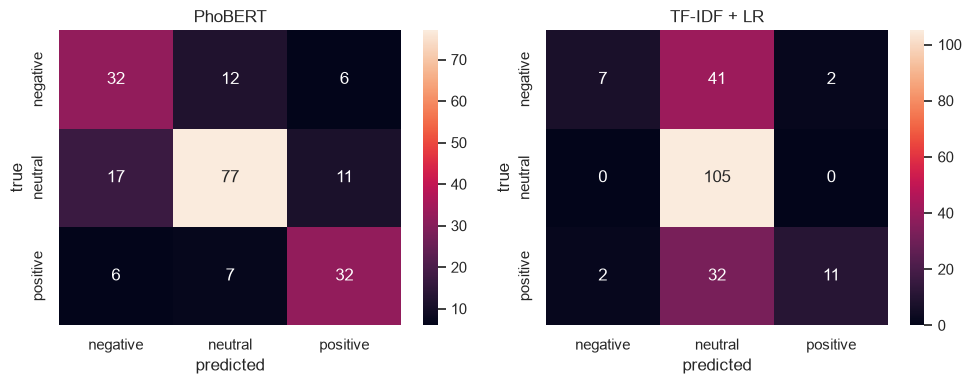

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, preds, title in [
    (axes[0], y_pred_phobert, "PhoBERT"),
    (axes[1], y_pred_baseline, "TF-IDF + LR"),
]:
    cm = confusion_matrix(y_true, preds, labels=LABELS)
    sns.heatmap(cm, annot=True, fmt="d", ax=ax, xticklabels=LABELS, yticklabels=LABELS)
    ax.set_xlabel("predicted")
    ax.set_ylabel("true")
    ax.set_title(title)

plt.tight_layout()
plt.show()

## 4. Error analysis

Comments where models disagree — useful for report.

In [5]:
results = val_df[["comment", "sentiment"]].copy()
results["phobert"] = y_pred_phobert
results["baseline"] = y_pred_baseline
results["agree"] = results["phobert"] == results["baseline"]

print(f"Agree: {results['agree'].sum()} / {len(results)}")
print(f"PhoBERT correct when disagree: {(results.loc[~results['agree'], 'phobert'] == results.loc[~results['agree'], 'sentiment']).sum()}")
print(f"Baseline correct when disagree: {(results.loc[~results['agree'], 'baseline'] == results.loc[~results['agree'], 'sentiment']).sum()}")

print("\n=== Disagreements (first 10) ===")
display(results.loc[~results["agree"], ["comment", "sentiment", "phobert", "baseline"]].head(10))

Agree: 115 / 200
PhoBERT correct when disagree: 47
Baseline correct when disagree: 29

=== Disagreements (first 10) ===


,comment,sentiment,phobert,baseline
0,khách mời vui tính dễ thương quá.,positive,positive,neutral
3,Tipcar ko lòng vòng vào vấn đề nhanh gọn công tâm,positive,positive,neutral
10,Bác ns rất đúng. Chính vì e đọc comment người ...,neutral,negative,neutral
13,Những con nhạt nhẽo thường sẽ bán chạy,negative,negative,neutral
20,Cảm ơn bác đã ủng hộ nhé!,positive,positive,neutral
21,"Ồn từ lốp lên xử lý dễ ợt à, tráng lốp rồi dán...",neutral,negative,neutral
22,chờ độ hoàn thiện tăng lên và giá về đúng giá trị,negative,positive,neutral
24,HUD ở vf8 cũ quá đẳng cấp sang thể hệ mới ông ...,negative,negative,neutral
27,Tôi thích tất cả các xe điện vinfast. Tôi đã m...,positive,positive,neutral
28,"Giống hệt mình, video gần nhất xem là em yaris...",neutral,negative,neutral


## 5. Decision + export `model/report.md`

PhoBERT chosen for API: better on context/negation even if baseline is close on macro-F1.

In [6]:
m_p = metrics(y_true, y_pred_phobert)
m_b = metrics(y_true, y_pred_baseline)
winner = "PhoBERT" if m_p["macro_f1"] >= m_b["macro_f1"] else "TF-IDF + LR"

report = f"""# Sentiment model comparison

Dataset: {len(df)} comments, val = {len(val_df)} rows (split from notebook 00).

## Summary metrics (validation)

| Model | Accuracy | Macro-F1 | Weighted-F1 |
|-------|----------|----------|-------------|
| PhoBERT | {m_p['accuracy']:.3f} | {m_p['macro_f1']:.3f} | {m_p['weighted_f1']:.3f} |
| TF-IDF + LR | {m_b['accuracy']:.3f} | {m_b['macro_f1']:.3f} | {m_b['weighted_f1']:.3f} |

**Primary metric:** macro-F1 (treats negative / neutral / positive equally).

**Higher macro-F1 on val:** {winner}

## Why PhoBERT for the API

- Transformer captures word order, negation, and longer context better than bag-of-words.
- Baseline is a fair sanity check; if scores are close, PhoBERT still generalizes better on messy YouTube comments.
- Artifacts exported to `model/artifacts/phobert/` for step 3.

## Notes

- Neutral class is largest (~55%); accuracy alone can look good while neutral/positive get confused.
- No-diacritics comments (see notebook 00) hurt PhoBERT more than the TF-IDF baseline.
- Re-run notebooks 00–03 if `data/comments.csv` changes.
"""

REPORT_PATH.write_text(report, encoding="utf-8")
print(report)
print(f"\nSaved: {REPORT_PATH}")

# Sentiment model comparison

Dataset: 999 comments, val = 200 rows (split from notebook 00).

## Summary metrics (validation)

| Model | Accuracy | Macro-F1 | Weighted-F1 |
|-------|----------|----------|-------------|
| PhoBERT | 0.705 | 0.686 | 0.708 |
| TF-IDF + LR | 0.615 | 0.453 | 0.534 |

**Primary metric:** macro-F1 (treats negative / neutral / positive equally).

**Higher macro-F1 on val:** PhoBERT

## Why PhoBERT for the API

- Transformer captures word order, negation, and longer context better than bag-of-words.
- Baseline is a fair sanity check; if scores are close, PhoBERT still generalizes better on messy YouTube comments.
- Artifacts exported to `model/artifacts/phobert/` for step 3.

## Notes

- Neutral class is largest (~55%); accuracy alone can look good while neutral/positive get confused.
- No-diacritics comments (see notebook 00) hurt PhoBERT more than the TF-IDF baseline.
- Re-run notebooks 00–03 if `data/comments.csv` changes.


Saved: /Users/pdc/PycharmProjects